# Analyzing the Interferograms generated using openEO API

This notebook demonstrates a hybrid approach to Sentinel-1 interferometric analysis. This notebook builds a small InSAR (SAR interferometry) time-series pipeline for ground-deformation monitoring using Sentinel‑1 data via openEO, over an area in central Italy that corresponds almost exactly to the Amatrice–Norcia earthquake zone (Aug 2016 sequence).

The computationally intensive part — generating Sentinel-1 interferograms from the original satellite observations — is executed remotely through the openEO API. This avoids downloading and processing the large amount of SAR data required to create the interferograms.

Once the interferogram products have been generated, the results are downloaded and analysed locally with Python. This separation illustrates one of the main advantages of openEO: large-scale Earth observation processing can be moved close to the data, while users can still use familiar Python tools for the analysis of the resulting products.

In [39]:
import glob
import re

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import openeo
import rasterio
from rasterio.transform import from_origin
from rasterio.warp import reproject, Resampling

### Connect to CDSE backend

Before requesting the interferogram, we connect to the Copernicus Data Space openEO backend and authenticate.

In [2]:

connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


## Define the Sentinel-1 interferogram request

Here we describe the interferogram we want to generate using an openEO process. Calls a community User-Defined Process (UDP) sentinel1_sar_interferogram (from the ESA-APEx algorithm catalog) that computes SAR interferograms from Sentinel‑1 data. The request selects the Sentinel-1 VV polarization, IW1 sub-swath, a spatial area in Italy, observations between August and November 2016, and a temporal baseline of six days.


The sentinel1_sar_interferogram process encapsulates the computationally intensive SAR processing needed to derive the interferogram products.

This is the first important cloud-processing step: instead of downloading the individual Sentinel-1 acquisitions and performing the interferometric processing locally, we send the processing request to the openEO backend.

In [3]:
s1_interferogram = connection.datacube_from_process(
    "sentinel1_sar_interferogram",
    namespace="https://raw.githubusercontent.com/ESA-APEx/apex_algorithms/refs/heads/main/algorithm_catalog/eurac/sentinel1_sar_interferogram/openeo_udp/sentinel1_sar_interferogram.json",
    polarization="VV",
    sub_swath="IW1",
    spatial_extent={
        "west": 13.10,
        "south": 42.60,
        "east": 13.38,
        "north": 42.78
    },
    temporal_baseline=6,
    temporal_extent = ["2016-08-18", "2016-11-18"]
)

The process graph is now submitted as a batch job to the openEO backend. The backend performs the actual interferogram generation using the Sentinel-1 data available in the cloud environment. This is where the computationally expensive part of the workflow happens in the cloud.

In [4]:
job = s1_interferogram.create_job(title="SAR interferogram VV only")
job.start_and_wait()

0:00:00 Job 'j-260825064348430d9cb8b1bd59665994': send 'start'
0:00:02 Job 'j-260825064348430d9cb8b1bd59665994': queued (progress 0%)
0:00:07 Job 'j-260825064348430d9cb8b1bd59665994': queued (progress 0%)
0:00:14 Job 'j-260825064348430d9cb8b1bd59665994': queued (progress 0%)
0:00:22 Job 'j-260825064348430d9cb8b1bd59665994': queued (progress 0%)
0:00:32 Job 'j-260825064348430d9cb8b1bd59665994': queued (progress 0%)
0:00:44 Job 'j-260825064348430d9cb8b1bd59665994': queued (progress 0%)
0:00:59 Job 'j-260825064348430d9cb8b1bd59665994': queued (progress 0%)
0:01:19 Job 'j-260825064348430d9cb8b1bd59665994': queued (progress 0%)
0:01:43 Job 'j-260825064348430d9cb8b1bd59665994': running (progress N/A)
0:02:13 Job 'j-260825064348430d9cb8b1bd59665994': running (progress N/A)
0:02:50 Job 'j-260825064348430d9cb8b1bd59665994': running (progress N/A)
0:03:37 Job 'j-260825064348430d9cb8b1bd59665994': running (progress N/A)
0:04:35 Job 'j-260825064348430d9cb8b1bd59665994': running (progress N/A)
0:05

<BatchJob job_id='j-260825064348430d9cb8b1bd59665994'>

## Download the job results

Download the returned files locally. This UDP provides one three-band GeoTIFF per interferogram pair.

In [5]:
result = job.get_results()
result.download_files("sar_interferogram/")  # NB: despite out_format="NetCDF" above, this UDP always
# returns one 3-band GeoTIFF per pair instead (see job-results.json) - handled in the loading cell below.

[WindowsPath('sar_interferogram/phase_coh_20160822T165740_20160828T165658.tif'),
 WindowsPath('sar_interferogram/phase_coh_20160828T165658_20160903T165740.tif'),
 WindowsPath('sar_interferogram/phase_coh_20160927T165741_20161003T165659.tif'),
 WindowsPath('sar_interferogram/phase_coh_20161003T165659_20161009T165741.tif'),
 WindowsPath('sar_interferogram/phase_coh_20161009T165741_20161015T165659.tif'),
 WindowsPath('sar_interferogram/phase_coh_20161015T165659_20161021T165741.tif'),
 WindowsPath('sar_interferogram/phase_coh_20161021T165741_20161027T165659.tif'),
 WindowsPath('sar_interferogram/phase_coh_20161027T165659_20161102T165741.tif'),
 WindowsPath('sar_interferogram/phase_coh_20161102T165741_20161108T165659.tif'),
 WindowsPath('sar_interferogram/phase_coh_20161108T165659_20161114T165741.tif'),
 WindowsPath('sar_interferogram/job-results.json')]

## Configure plot styling

Set shared Matplotlib defaults for the interferogram quicklook and deformation figures.

In [6]:
# Cleaner defaults for the figures further down
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#c3c2b7",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 12,
})

## Load and inspect the GeoTIFF pairs

Read each three-band GeoTIFF, identify its wrapped phase, unwrapped phase, and coherence bands, then record the pair date and spatial metadata.

Each GeoTIFF's three bands are identified by their descriptions: wrapped phase, unwrapped phase, coherence. Since each pair has a slightly different footprint (due to orbit geometry), all pairs are reprojected onto one common grid and stacked into an xarray.Dataset with a time dimension — this is essentially building your own lightweight time-series data cube. A quicklook plot checks that the bands look sane.

In [9]:
# The job returns one 3-band GeoTIFF per interferogram pair (wrapped phase,
# unwrapped phase, coherence), not a single NetCDF cube - "sar_interferogram/openEO.nc"
# is a leftover from an unrelated earlier run (different polarization/date range)
# and isn't part of this job's output, so the cube is built here from the GeoTIFFs.
tif_paths = sorted(glob.glob("sar_interferogram/phase_coh_*.tif"))
pair_re = re.compile(r"phase_coh_(\d{8}T\d{6})_\d{8}T\d{6}\.tif$")


pairs = []
crs = None
for path in tif_paths:
    with rasterio.open(path) as src:
        desc = [d.lower() for d in src.descriptions]
        wrapped_idx = next(i for i, d in enumerate(desc) if "phase" in d and "unw" not in d)
        unwrapped_idx = next(i for i, d in enumerate(desc) if "unw" in d)
        coh_idx = next(i for i, d in enumerate(desc) if "coh" in d)
        data = src.read()
        transform, shape = src.transform, src.shape
        crs = src.crs
        print(f"Loaded {path} of shape: {shape}")
    pairs.append({
        "date": pd.Timestamp(pair_re.search(path).group(1)),
        "wrapped": data[wrapped_idx],
        "unwrapped": data[unwrapped_idx],
        "coherence": data[coh_idx],
        "transform": transform,
        "shape": shape,
    })
pairs.sort(key=lambda p: p["date"])
print(f"Loaded {len(pairs)} interferogram pairs from {len(tif_paths)} GeoTIFFs, CRS: {crs}")

Loaded sar_interferogram\phase_coh_20160822T165740_20160828T165658.tif of shape: (1914, 6520)
Loaded sar_interferogram\phase_coh_20160828T165658_20160903T165740.tif of shape: (1914, 6521)
Loaded sar_interferogram\phase_coh_20160927T165741_20161003T165659.tif of shape: (1914, 6521)
Loaded sar_interferogram\phase_coh_20161003T165659_20161009T165741.tif of shape: (1856, 6291)
Loaded sar_interferogram\phase_coh_20161009T165741_20161015T165659.tif of shape: (1914, 6520)
Loaded sar_interferogram\phase_coh_20161015T165659_20161021T165741.tif of shape: (1863, 6339)
Loaded sar_interferogram\phase_coh_20161021T165741_20161027T165659.tif of shape: (1914, 6521)
Loaded sar_interferogram\phase_coh_20161027T165659_20161102T165741.tif of shape: (1863, 6339)
Loaded sar_interferogram\phase_coh_20161102T165741_20161108T165659.tif of shape: (1914, 6521)
Loaded sar_interferogram\phase_coh_20161108T165659_20161114T165741.tif of shape: (1863, 6340)
Loaded 10 interferogram pairs from 10 GeoTIFFs, CRS: EPSG:43

Reproject every pair onto a shared raster grid so the time dimension can be stacked and compared pixel by pixel.

In [13]:
# Each pair's raw footprint/shape differs slightly (orbit geometry), so reproject
# every pair onto one shared grid before stacking them into a (time, y, x) cube.
res_x, res_y = abs(pairs[0]["transform"].a), abs(pairs[0]["transform"].e)
xmin = min(p["transform"].c for p in pairs)
ymax = max(p["transform"].f for p in pairs)
xmax = max(p["transform"].c + p["shape"][1] * p["transform"].a for p in pairs)
ymin = min(p["transform"].f + p["shape"][0] * p["transform"].e for p in pairs)
width = int(round((xmax - xmin) / res_x))
height = int(round((ymax - ymin) / res_y))
dst_transform = from_origin(xmin, ymax, res_x, res_y)

def align(band, transform):
    dst = np.full((height, width), np.nan, dtype="float32")
    reproject(source=band, destination=dst, src_transform=transform, src_crs=crs,
              dst_transform=dst_transform, dst_crs=crs, src_nodata=np.nan, dst_nodata=np.nan,
              resampling=Resampling.nearest)  # nearest avoids blending across the phase wrap
    return dst

ds = xr.Dataset(
    {
        "wrapped_phase": (("time", "y", "x"), np.stack([align(p["wrapped"], p["transform"]) for p in pairs])),
        "unwrapped_phase": (("time", "y", "x"), np.stack([align(p["unwrapped"], p["transform"]) for p in pairs])),
        "coherence": (("time", "y", "x"), np.stack([align(p["coherence"], p["transform"]) for p in pairs])),
    },
    coords={
        "time": pd.DatetimeIndex([p["date"] for p in pairs]),
        "y": ymax - res_y * (np.arange(height) + 0.5),
        "x": xmin + res_x * (np.arange(width) + 0.5),
    },
).sortby("time")

print(f"Aligned cube shape: {ds['coherence'].shape}")
print(f"Bands in the cube: {list(ds.data_vars)}")

Aligned cube shape: (10, 1924, 6622)
Bands in the cube: ['wrapped_phase', 'unwrapped_phase', 'coherence']


## Create a quicklook of the interferogram bands

Display wrapped phase, unwrapped phase, and coherence for one pair to check the downloaded and aligned data visually.

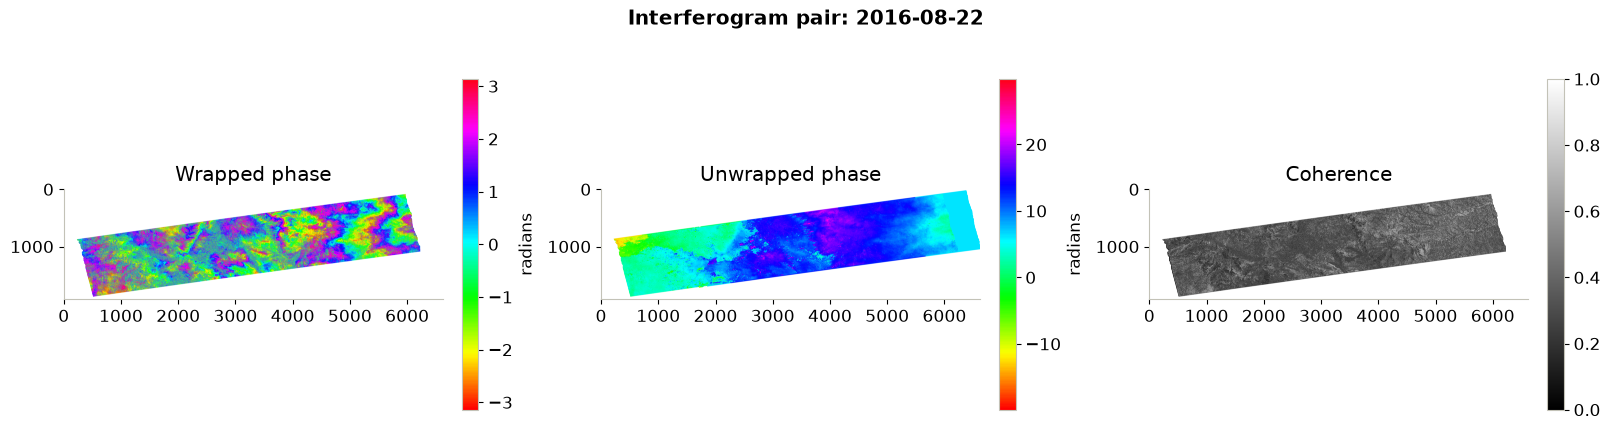

In [15]:
# Quicklook: second pair in the stack
fig, axs = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
im0 = axs[0].imshow(ds["wrapped_phase"].isel(time=1), cmap="hsv")
axs[0].set_title("Wrapped phase")
fig.colorbar(im0, ax=axs[0], label="radians", shrink=0.8)
im1 = axs[1].imshow(ds["unwrapped_phase"].isel(time=1), cmap="hsv")
axs[1].set_title("Unwrapped phase")
fig.colorbar(im1, ax=axs[1], label="radians", shrink=0.8)
im2 = axs[2].imshow(ds["coherence"].isel(time=1), cmap="gray", vmin=0, vmax=1)
axs[2].set_title("Coherence")
fig.colorbar(im2, ax=axs[2], shrink=0.8)
for ax in axs:
    ax.grid(False)
fig.suptitle(f"Interferogram pair: {pd.Timestamp(ds['wrapped_phase'].time.values[0]).date()}", fontweight="bold")
plt.show()

## Step 1: Convert unwrapped phase to line-of-sight displacement

The unwrapped phase (in radians) is converted to displacement using:
- **d = -(λ/4π) × Δφ**
- λ (wavelength) for Sentinel-1 VV = 0.0554 m
- Negative values = motion away from satellite (subsidence)
- Positive values = motion toward satellite (uplift)

In [21]:
LAMBDA_M = 0.05546          # Sentinel-1 C-band wavelength [m]
COHERENCE_THRESHOLD = 0.50  # mask pixels below this coherence
GRADIENT_PERCENTILE = 98    # flag steepest local-phase-gradient pixels as artifacts (per pair)

displacement = -(LAMBDA_M / (4 * np.pi)) * ds["unwrapped_phase"]  # convert unwrapped phase to line-of-sight displacement [m]

## Identify steep phase-gradient artifacts

Measure local phase gradients and mark the steepest pixels as likely residual unwrapping artifacts.

In [22]:
# Flag pixels with a very steep local phase gradient in each pair - usually a
# residual fringe / unwrapping error rather than real ground motion.
res_y = float(abs(ds.y[1] - ds.y[0]))
res_x = float(abs(ds.x[1] - ds.x[0]))
dy, dx = np.gradient(ds["unwrapped_phase"].values, res_y, res_x, axis=(1, 2))
gradient_mag = np.hypot(dx, dy)
gradient_cutoff = np.nanpercentile(gradient_mag, GRADIENT_PERCENTILE, axis=(1, 2), keepdims=True)
print(f"Gradient cutoff (98th percentile) per pair: {gradient_cutoff.flatten()}")

Gradient cutoff (98th percentile) per pair: [14794.885 14765.238 16752.332 17410.479 16683.742 15408.414 15845.177
 14510.612 15859.367 15214.134]


## Mask unreliable displacement values

Remove pixels with low coherence or extreme phase gradients so the deformation trend uses only plausible measurements.

In [23]:
unreliable = (ds["coherence"].values < COHERENCE_THRESHOLD) | (gradient_mag >= gradient_cutoff)
displacement = displacement.where(~unreliable)
print(f"Displacement cube shape: {displacement.shape}, valid fraction per pair: {displacement.notnull().mean(dim=('y', 'x')).values}")

Displacement cube shape: (10, 1924, 6622), valid fraction per pair: [0.12597459 0.12238932 0.13288314 0.10770742 0.15729062 0.15217686
 0.16145914 0.13822091 0.12489906 0.13644738]


## Report the retained data fraction

Calculate how much valid displacement data remains for each interferogram pair after quality masking.

Flags unreliable pixels two ways: (a) low coherence (<0.5, a decorrelation/noise indicator), and (b) steep local phase gradients (98th percentile), which usually indicate residual unwrapping artifacts rather than real motion. Reports what fraction of pixels survive per pair.

In [24]:
valid_fraction = displacement.notnull().mean(dim=("y", "x"))
for t, frac in zip(pd.to_datetime(displacement.time.values), valid_fraction.values):
    print(f"{t.date()}: {frac:.1%} pixels retained after coherence/gradient masking")

2016-08-22: 12.6% pixels retained after coherence/gradient masking
2016-08-28: 12.2% pixels retained after coherence/gradient masking
2016-09-27: 13.3% pixels retained after coherence/gradient masking
2016-10-03: 10.8% pixels retained after coherence/gradient masking
2016-10-09: 15.7% pixels retained after coherence/gradient masking
2016-10-15: 15.2% pixels retained after coherence/gradient masking
2016-10-21: 16.1% pixels retained after coherence/gradient masking
2016-10-27: 13.8% pixels retained after coherence/gradient masking
2016-11-02: 12.5% pixels retained after coherence/gradient masking
2016-11-08: 13.6% pixels retained after coherence/gradient masking


## Step 2: Fit a linear deformation trend over time

The job returns one GeoTIFF per pair, each on a slightly different footprint from orbit geometry, so the loading cell above already reprojected every pair onto one shared grid before stacking - no further reprojection/alignment is needed here.

Rather than a running cumulative sum, each pixel's displacement history is fit with a straight line through time (least squares, using only that pixel's valid/unmasked pairs). A cumulative sum silently treats a masked pair as "zero displacement" for that step, which biases the total low — and biases it most where deformation is largest, since strong deformation is also what causes decorrelation and masking. A per-pixel linear fit only uses the pairs that actually have data, so masked pairs and the mid-September data gap don't drag pixels toward zero.

Rather than a running cumulative sum (which would bias masked pairs toward "zero displacement"), each pixel's valid displacement observations are fit with a least-squares straight line vs. time (velocity + intercept), solved as a batched 2×2 linear system with np.linalg.solve. This gives a velocity map (mm/yr) and a total-displacement map robust to gaps/masking.

In [26]:
displacement_stack = displacement.values  # (pair, y, x), already on a common grid
dates = pd.to_datetime(displacement.time.values)
print(f"Dates of interferogram pairs: {[d.date() for d in dates]}")
t_days = (dates - dates[0]).days.to_numpy(dtype="float64")
t = t_days[:, None, None]

Dates of interferogram pairs: [datetime.date(2016, 8, 22), datetime.date(2016, 8, 28), datetime.date(2016, 9, 27), datetime.date(2016, 10, 3), datetime.date(2016, 10, 9), datetime.date(2016, 10, 15), datetime.date(2016, 10, 21), datetime.date(2016, 10, 27), datetime.date(2016, 11, 2), datetime.date(2016, 11, 8)]


## Count valid observations per pixel

Build validity masks and identify pixels with at least two usable observations for a fitted deformation trend.

In [27]:
valid = ~np.isnan(displacement_stack)
y = np.where(valid, displacement_stack, 0.0)
n_valid = valid.sum(axis=0)
n_valid_f = n_valid.astype("float64")
enough_data = n_valid >= 2
print(f"Pixels with enough data for linear regression: {enough_data.mean():.1%} of the area")

Pixels with enough data for linear regression: 27.0% of the area


## Fit the deformation trend

Solve a batched least-squares line fit for velocity and intercept at every pixel using only its valid observations.

In [32]:
# Per-pixel weighted linear fit (velocity, intercept) via numpy's batched linear-algebra
# solver on the normal equations for y = velocity*t + intercept:
#   [[Σt², Σt], [Σt, n]] @ [velocity, intercept] = [Σty, Σy]
# Masked pairs get weight 0 (via `valid`), so only a pixel's actually-valid pairs
# contribute - same masked-pairs handling as before, just solved with np.linalg.solve
# instead of a hand-rolled Cramer's-rule division.
sum_t = np.where(valid, t, 0.0).sum(axis=0)
sum_tt = np.where(valid, t ** 2, 0.0).sum(axis=0)
sum_y = y.sum(axis=0)
sum_ty = (t * y).sum(axis=0)

A = np.stack([
    np.stack([sum_tt, sum_t], axis=-1),
    np.stack([sum_t, n_valid_f], axis=-1),
], axis=-2)  # (y, x, 2, 2)
b = np.stack([sum_ty, sum_y], axis=-1)  # (y, x, 2)

det = sum_tt * n_valid_f - sum_t ** 2
print(f"Determinant min: {np.nanmin(det)}, max: {np.nanmax(det)}")
solvable = enough_data & (det != 0)  # skip pixels with <2 valid pairs or a singular design (e.g. duplicate dates)
print(f"Valid pixels: {np.sum(solvable)} out of {solvable.size} ({100 * np.sum(solvable) / solvable.size:.1f}%)")


Determinant min: 0.0, max: 61681.0
Valid pixels: 3436696 out of 12740728 (27.0%)


## Solve the per-pixel linear systems

Solve the normal equations for each usable pixel, then derive total displacement over the observation period and the annualized velocity.

In [33]:
velocity = np.full(n_valid.shape, np.nan)
intercept = np.full(n_valid.shape, np.nan)
# b needs an explicit trailing axis here - without it, this numpy version misdetects
# the (K,2,2)/(K,2) batched-solve1 case and raises a core-dimension ValueError.
coeffs = np.linalg.solve(A[solvable], b[solvable][..., None])[..., 0]  # batched 2x2 solve, one per solvable pixel
velocity[solvable] = coeffs[:, 0]  # m/day, line-of-sight
intercept[solvable] = coeffs[:, 1]

total_displacement = velocity * t_days[-1] + intercept  # NaN propagates automatically where unsolved

print(f"Total displacement range: {np.nanmin(total_displacement):.3f} to {np.nanmax(total_displacement):.3f} m")
print(f"Peak LOS velocity: {np.nanmax(np.abs(velocity)) * 1000:.0f} mm/yr")

Total displacement range: -2.754 to 1.936 m
Peak LOS velocity: 50 mm/yr


## Step 3: Visualize the displacement map

Plot the net line-of-sight displacement and the underlying LOS velocity over the whole period, from the linear-trend fit above.
- **Red** = motion toward satellite (positive displacement/velocity)
- **Blue** = motion away from satellite (negative displacement/velocity)
- **White/blank** = pixels with fewer than 2 valid pairs (masked by coherence or phase-gradient filtering)

Map extent: 12.7236 to 13.9131°E, 42.3933 to 42.7388°N
Velocity range: -13479.6 to 18407.2 mm/yr


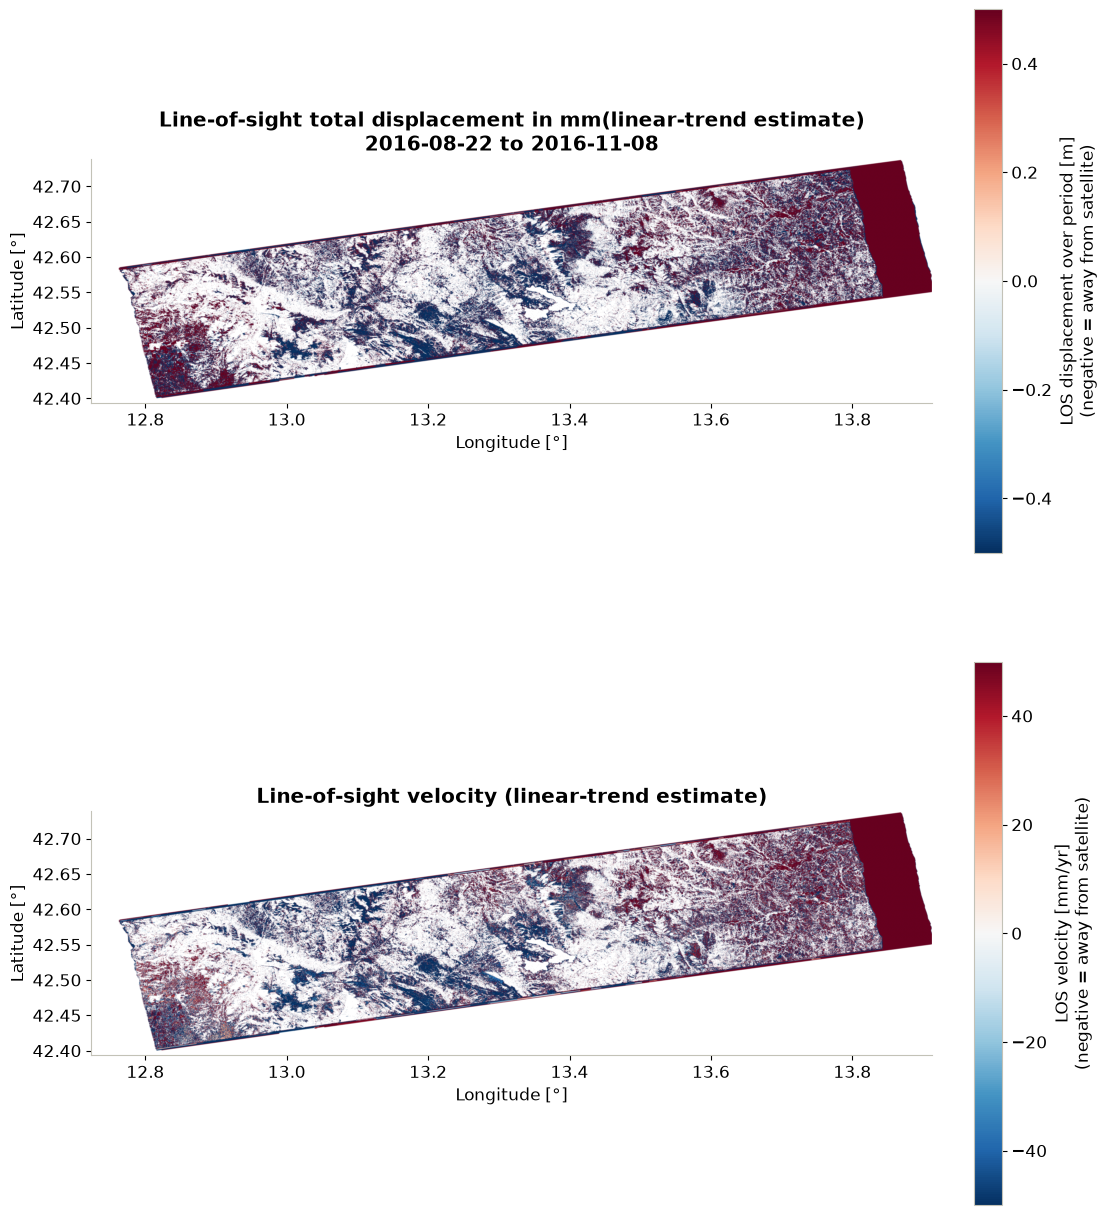

In [34]:
# Prepare extent (AOI was requested in EPSG:4326, so the axes are lon/lat)
extent = [float(displacement.x.min()), float(displacement.x.max()),
          float(displacement.y.min()), float(displacement.y.max())]
print(f"Map extent: {extent[0]:.4f} to {extent[1]:.4f}°E, {extent[2]:.4f} to {extent[3]:.4f}°N")

velocity_mm_yr = velocity*1000*365   #  mm/yr, easier to read than m/day
print(f"Velocity range: {np.nanmin(velocity_mm_yr):.1f} to {np.nanmax(velocity_mm_yr):.1f} mm/yr")

fig, axs = plt.subplots(2, 1, figsize=(11, 13), constrained_layout=True)
for ax in axs:
    ax.grid(False)
    ax.set_xlabel("Longitude [°]")
    ax.set_ylabel("Latitude [°]")

im0 = axs[0].imshow(total_displacement*1000, cmap="RdBu_r", vmin=-0.5, vmax=0.5,
                     extent=extent, origin="upper", interpolation="bilinear")
axs[0].set_title("Line-of-sight total displacement in mm(linear-trend estimate)\n" +
                  f"{dates[0].date()} to {dates[-1].date()}", fontweight="bold")
fig.colorbar(im0, ax=axs[0], shrink=0.85, label="LOS displacement over period [m]\n(negative = away from satellite)")

im1 = axs[1].imshow(velocity_mm_yr, cmap="RdBu_r", vmin=-50.0, vmax=50.0,
                     extent=extent, origin="upper", interpolation="bilinear")
axs[1].set_title("Line-of-sight velocity (linear-trend estimate)", fontweight="bold")
fig.colorbar(im1, ax=axs[1], shrink=0.85, label="LOS velocity [mm/yr]\n(negative = away from satellite)")

plt.show()



## Step 4: Trend at the peak-deformation pixel

Find the pixel with the largest fitted displacement and show its raw per-pair measurements against the fitted linear trend — this makes it clear the map above comes from a line fit through noisy, partly-masked data, not a literal running total.

In [37]:
# Find the pixel with the largest fitted displacement
peak_y, peak_x = np.unravel_index(np.nanargmax(np.abs(total_displacement)), total_displacement.shape)
print(f"Peak deformation pixel: row {peak_y}, col {peak_x}")
print(f"Fitted displacement over the period: {total_displacement[peak_y, peak_x]:.3f} m")

pixel_displacement = displacement_stack[:, peak_y, peak_x]
pixel_velocity = velocity[peak_y, peak_x]
pixel_intercept = intercept[peak_y, peak_x]
print(f"Fitted velocity: {pixel_velocity * 365.25 * 1000:.0f} mm/yr "
      f"({'toward satellite' if pixel_velocity > 0 else 'away from satellite'})")


Peak deformation pixel: row 905, col 2620
Fitted displacement over the period: -2.754 m
Fitted velocity: -13489 mm/yr (away from satellite)


## Plot the peak-deformation pixel

Compare the selected pixel's valid per-pair displacement measurements with its fitted linear trend.

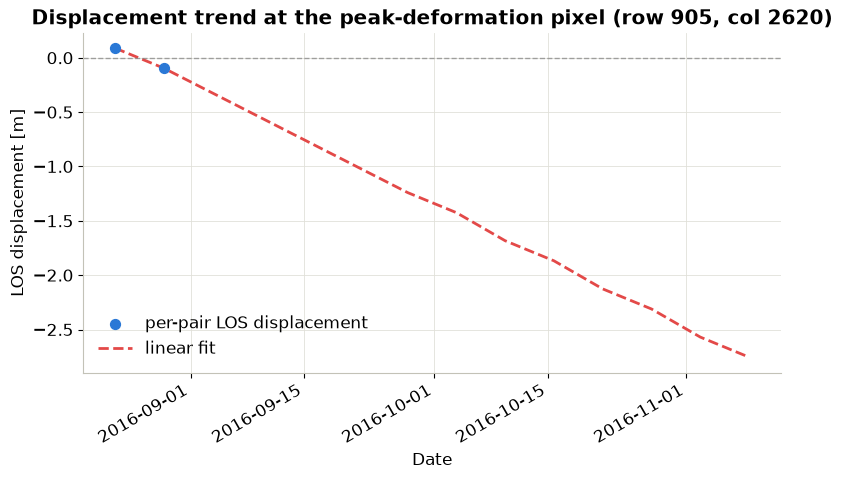

In [38]:
# Plot the raw per-pair measurements against the fitted trend
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(dates, pixel_displacement, s=50, color="#2a78d6", zorder=3, label="per-pair LOS displacement")
fit_line = pixel_velocity * t_days + pixel_intercept
ax.plot(dates, fit_line, color="#e34948", linestyle="--", linewidth=2, label="linear fit")
ax.axhline(0, color="grey", linewidth=1, linestyle="--", alpha=0.7)

ax.set_ylabel("LOS displacement [m]")
ax.set_xlabel("Date")
ax.set_title(f"Displacement trend at the peak-deformation pixel (row {peak_y}, col {peak_x})", fontweight="bold")
ax.legend(frameon=False)

fig.autofmt_xdate()  # rotate date labels
plt.show()